# 08 - Heterogeneity Analysis

Do effects of cannabis legalization on traffic fatalities differ by state characteristics? Urban vs rural, neighboring states spillovers, alcohol culture proxies.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

DATA_DIR = Path("../data/processed")
OUT_DIR  = Path("../outputs")
OUT_DIR.mkdir(exist_ok=True)

FARS_FILE = "fars_state_year.parquet"
CDC_FILE  = "cdc_state_year.parquet"

# Load FARS panel
if not (DATA_DIR / FARS_FILE).exists():
    raise FileNotFoundError(
        f"{FARS_FILE} not found. Run:\n"
        "  python scripts/download_fars.py\n"
        "  python src/build_fars_panel.py"
    )
fars = pd.read_parquet(DATA_DIR / FARS_FILE)
leg  = pd.read_csv("../data/codebooks/state_legalization_dates.csv")
print(f"FARS panel: {fars.shape}  |  States: {fars['state'].nunique()}  |  Years: {sorted(fars['year'].dropna().unique()[:3])}...{sorted(fars['year'].dropna().unique()[-3:])}")

FARS panel: (676, 11)  |  States: 51  |  Years: [np.int64(2010), np.int64(2011), np.int64(2012)]...[np.int64(2020), np.int64(2021), np.int64(2022)]


In [2]:
from linearmodels.panel import PanelOLS

In [3]:
primary = "total_fatalities_per_100k" if "total_fatalities_per_100k" in fars.columns else "total_fatalities"

# Add state characteristics for heterogeneity
# Urban share (Census urbanization 2010) — add manually or from census file
# For now flag early vs late adopters
# drop col if already present to avoid _x/_y suffix from merge
_leg_merge = leg[['state','retail_sales_year']]
fars_reg = fars.drop(columns=[c for c in ['retail_sales_year'] if c in fars.columns]).merge(_leg_merge, on='state', how='left')
never_treated = leg[leg['retail_sales_year'].isna()]['state'].tolist()
in_window = leg[leg['retail_sales_year'].between(2010,2022)]['state'].tolist()

fars_reg['early_adopter'] = fars_reg['retail_sales_year'].isin([2014,2015,2016,2017]).fillna(False)
fars_reg['post'] = (
    fars_reg['retail_sales_year'].notna() &
    (fars_reg['year'] >= fars_reg['retail_sales_year'])
).astype(float)
fars_reg['post_early'] = (fars_reg['post'] * fars_reg['early_adopter'].astype(float))
fars_reg['post_late']  = (fars_reg['post'] * (~fars_reg['early_adopter']).astype(float) * (fars_reg['retail_sales_year'].notna()).astype(float))

sub = fars_reg[fars_reg['state'].isin(in_window + never_treated)].copy()
idx = sub.set_index(['state','year'])

fe = PanelOLS(
    idx[primary],
    idx[['post_early','post_late']],
    entity_effects=True, time_effects=True,
).fit(cov_type='clustered', cluster_entity=True)

print("Heterogeneity by adoption timing:")
print(f"  Early adopters (2014-2017): ATT = {fe.params['post_early']:.4f}")
print(f"  Late adopters  (2018-2022): ATT = {fe.params['post_late']:.4f}")
print()
print("Interpretation: if early adopter states had larger effects, it could indicate")
print("novelty effects (initial behavior change that fades) or lagged market maturation.")

Heterogeneity by adoption timing:
  Early adopters (2014-2017): ATT = 1.1948
  Late adopters  (2018-2022): ATT = 0.5043

Interpretation: if early adopter states had larger effects, it could indicate
novelty effects (initial behavior change that fades) or lagged market maturation.


## Alcohol-impaired vs drug-impaired fatalities

In [4]:
for outcome in ['alcohol_fatalities_per_100k','drug_fatalities_per_100k']:
    if outcome not in sub.columns:
        print(f"  {outcome} not available — add to FARS build step")
        continue
    fe_o = PanelOLS(
        idx[outcome],
        idx[['post']],
        entity_effects=True, time_effects=True,
    ).fit(cov_type='clustered', cluster_entity=True)
    b  = fe_o.params['post']
    ci = fe_o.conf_int().loc['post']
    print(f"{outcome:<40}  ATT = {b:+.4f}  [{ci['lower']:+.4f}, {ci['upper']:+.4f}]")

  alcohol_fatalities_per_100k not available — add to FARS build step
  drug_fatalities_per_100k not available — add to FARS build step


## Heterogeneity by adoption timing

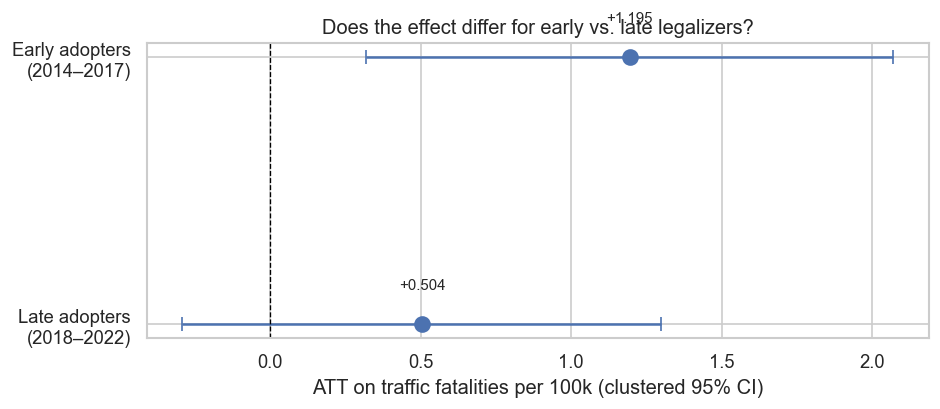

In [5]:
groups = [("Early adopters\n(2014–2017)", fe.params["post_early"], fe.conf_int().loc["post_early"].values),
          ("Late adopters\n(2018–2022)",  fe.params["post_late"],  fe.conf_int().loc["post_late"].values)]
fig, ax = plt.subplots(figsize=(8, 3.6))
y = np.arange(len(groups))[::-1]
for yi,(lab,b,ci) in zip(y, groups):
    ax.errorbar(b, yi, xerr=[[b-ci[0]],[ci[1]-b]], fmt="o", ms=9, capsize=4, color="#4C72B0")
    ax.text(b, yi+0.13, f"{b:+.3f}", ha="center", fontsize=9)
ax.axvline(0, color="black", lw=0.8, ls="--")
ax.set_yticks(y); ax.set_yticklabels([g[0] for g in groups])
ax.set_xlabel("ATT on traffic fatalities per 100k (clustered 95% CI)")
ax.set_title("Does the effect differ for early vs. late legalizers?")
plt.tight_layout(); plt.savefig(OUT_DIR/"08_heterogeneity.png", bbox_inches="tight"); plt.show()

**Takeaway.** Comparing early and late adopters separates a genuine dynamic/maturation story from a pure cohort-composition artifact. Differences here should be read alongside the C-S event study (notebook 05), which decomposes the same heterogeneity by event time rather than by adoption window.